

---



---



In [ ]:
!pip install tensorflow

In [ ]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.spatial.transform import Rotation as R
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.optimizers import Adam

# =========================
# LOAD + PREPROCESS
# =========================
def load_data(imu_path, gt_path):
    # Load IMU
    imu = pd.read_csv(imu_path, delim_whitespace=True)
    imu.columns = ["timestamp", "wx", "wy", "wz", "ax", "ay", "az"]

    # Load GT
    gt = pd.read_csv(gt_path)
    gt.columns = ["timestamp", "tx", "ty", "tz", "qw", "qx", "qy", "qz"]

    # Convert timestamp to seconds
    # imu["timestamp"] = imu["timestamp"] / 1e9
    # gt["timestamp"] = gt["timestamp"] / 1e9

    # =========================
    # INTERPOLATION (GT → IMU)
    # =========================
    gt_interp = {}

    for col in ["qw", "qx", "qy", "qz"]:
        f = interp1d(gt["timestamp"], gt[col],
                     kind='linear',
                     fill_value="extrapolate")
        gt_interp[col] = f(imu["timestamp"])

    gt_interp = pd.DataFrame(gt_interp)

    # =========================
    # QUATERNION → EULER
    # =========================
    quat = gt_interp[["qx", "qy", "qz", "qw"]].values
    r = R.from_quat(quat)
    euler = r.as_euler('xyz', degrees=False)  # roll, pitch, yaw

    # Add magnitude features:
    imu["acc_mag"] = np.sqrt(imu["ax"]**2 + imu["ay"]**2 + imu["az"]**2)
    imu["gyro_mag"] = np.sqrt(imu["wx"]**2 + imu["wy"]**2 + imu["wz"]**2)

    # Add delta time
    imu["dt"] = imu["timestamp"].diff().fillna(0)

    # Inputs (IMU)
    # X = imu[["wx", "wy", "wz", "ax", "ay", "az"]].values
    # X = imu[["wx","wy","wz","ax","ay","az","acc_mag","gyro_mag"]].values
    X = imu[["wx","wy","wz","ax","ay","az","acc_mag","gyro_mag","dt"]].values

    # Outputs (angles)
    y = euler

    return X, y


# =========================
# CREATE SEQUENCES
# =========================
def create_sequences(X, y, seq_len=30):
    X_seq, y_seq = [], []

    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])

    return np.array(X_seq), np.array(y_seq)


# =========================
# LOAD DATA (3 ROOMS)
# =========================
X_train, y_train = load_data("r1imu.txt", "r1gt_imu.csv")
X_val, y_val     = load_data("r2imu.txt", "r2gt_imu.csv")
X_test, y_test   = load_data("r3imu.txt", "r3gt_imu.csv")


# =========================
# NORMALIZATION
# =========================
x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train)
y_val   = y_scaler.transform(y_val)
y_test  = y_scaler.transform(y_test)


# =========================
# SEQUENCE CREATION
# =========================
# SEQ_LEN = 30
# SEQ_LEN = 20
SEQ_LEN = 25

X_train, y_train = create_sequences(X_train, y_train, SEQ_LEN)
X_val, y_val     = create_sequences(X_val, y_val, SEQ_LEN)
X_test, y_test   = create_sequences(X_test, y_test, SEQ_LEN)


# =========================
# MODEL (Simple RNN)
# =========================
# model = Sequential([
#     SimpleRNN(64, return_sequences=True, input_shape=(SEQ_LEN, 6)),
#     Dropout(0.2),
#     SimpleRNN(64),
#     Dense(32, activation='relu'),
#     Dense(3)  # roll, pitch, yaw
# ])
# model = Sequential([
#     SimpleRNN(32, return_sequences=True, input_shape=(SEQ_LEN, 6)),
#     Dropout(0.3),
#     SimpleRNN(32),
#     Dense(16, activation='relu'),
#     Dense(3)  # roll, pitch, yaw
# ])
model = Sequential([
    SimpleRNN(48, return_sequences=True, input_shape=(SEQ_LEN, 9)),
    Dropout(0.3),
    SimpleRNN(32),
    Dense(32, activation='relu'),
    Dense(3)  # roll, pitch, yaw
])

# model.compile(
#     optimizer='adam',
#     loss='mse',
#     metrics=['mae']
# )
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

model.summary()


# =========================
# TRAINING
# =========================
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

# history = model.fit(
#     X_train, y_train,
#     validation_data=(X_val, y_val),
#     epochs=50,
#     batch_size=64,
#     callbacks=[early_stop]
# )
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    shuffle=True,
    callbacks=[early_stop]
)


# =========================
# TESTING
# =========================
loss, mae = model.evaluate(X_test, y_test)
print("Test MAE:", mae)


# =========================
# PREDICTION
# =========================
y_pred = model.predict(X_test)

# Convert back to real angles
y_pred = y_scaler.inverse_transform(y_pred)
y_test = y_scaler.inverse_transform(y_test)

# =========================
# QUATERNION ERROR FUNCTION
# =========================
def normalize_quaternion(q):
    return q / np.linalg.norm(q, axis=1, keepdims=True)

def quaternion_angle_error(q1, q2):
    q1 = normalize_quaternion(q1)
    q2 = normalize_quaternion(q2)

    dot = np.sum(q1 * q2, axis=1)
    dot = np.clip(dot, -1.0, 1.0)

    theta = 2 * np.arccos(np.abs(dot))
    return theta

# =========================
# EULER → QUATERNION
# =========================
r_pred = R.from_euler('xyz', y_pred)
q_pred = r_pred.as_quat()

r_gt = R.from_euler('xyz', y_test)
q_gt = r_gt.as_quat()

# =========================
# FINAL ERROR
# =========================
angle_error = quaternion_angle_error(q_gt, q_pred)

print("Mean Orientation Error (radians):", np.mean(angle_error))
print("Mean Orientation Error (degrees):", np.degrees(np.mean(angle_error)))


# =========================
# SAVE RESULTS
# =========================
np.save("y_pred.npy", y_pred)
np.save("y_test.npy", y_test)
np.save("angle_error.npy", angle_error)

print("Saved predictions and ground truth!")
print("All results saved successfully!")

/tmp/ipykernel_14525/3702095882.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  imu = pd.read_csv(imu_path, delim_whitespace=True)
/tmp/ipykernel_14525/3702095882.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  imu = pd.read_csv(imu_path, delim_whitespace=True)
/tmp/ipykernel_14525/3702095882.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  imu = pd.read_csv(imu_path, delim_whitespace=True)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 25, 48)         │         2,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 32)             │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,531 (25.51 KB)

 Trainable params: 6,531 (25.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - loss: 0.6705 - mae: 0.6226 - val_loss: 0.5978 - val_mae: 0.5523
Epoch 2/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - loss: 0.4917 - mae: 0.5231 - val_loss: 0.5926 - val_mae: 0.5423
Epoch 3/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.4321 - mae: 0.4826 - val_loss: 0.5862 - val_mae: 0.5374
Epoch 4/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.4008 - mae: 0.4610 - val_loss: 0.6015 - val_mae: 0.5487
Epoch 5/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.3753 - mae: 0.4446 - val_loss: 0.5952 - val_mae: 0.5439
Epoch 6/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.3558 - mae: 0.4311 - val_loss: 0.5978 - val_mae: 0.5319
Epoch 7/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.3403 - mae: 0.4205 - val_loss: 0.5864 - val_mae: 0.5346
Epoch 8/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.3243 - mae: 0.4118 - val_loss: 0.6083 - val_mae: 0.5507
967/967 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step -

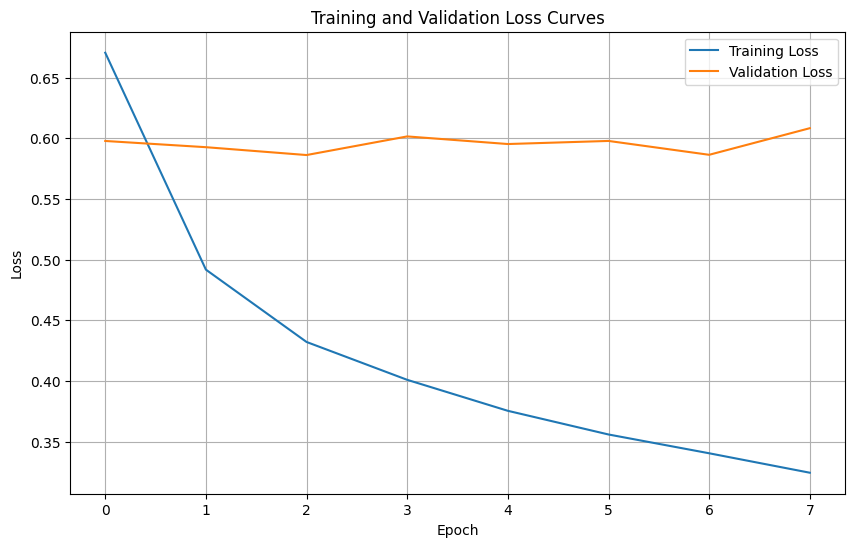

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

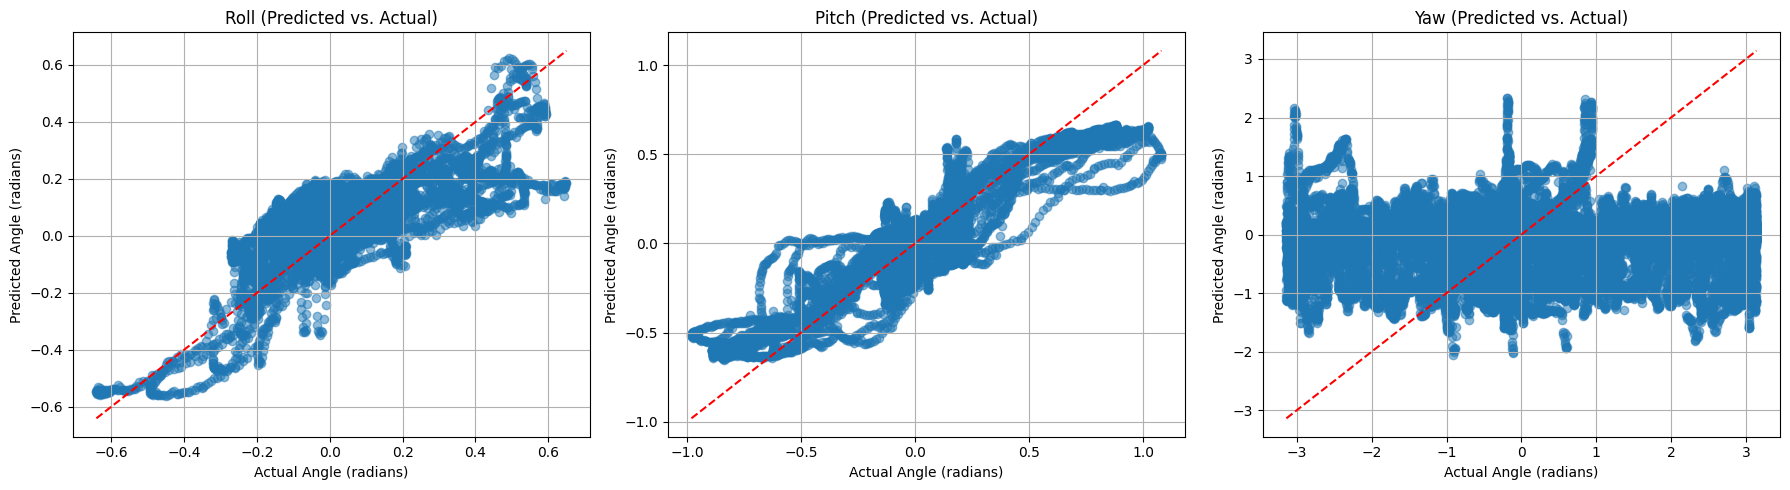

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load the saved predictions and ground truth
y_pred = np.load("y_pred.npy")
y_test = np.load("y_test.npy")

# Create subplots for each angle
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

labels = ['Roll', 'Pitch', 'Yaw']

for i in range(3):
    axes[i].scatter(y_test[:, i], y_pred[:, i], alpha=0.5)
    axes[i].set_title(f'{labels[i]} (Predicted vs. Actual)')
    axes[i].set_xlabel('Actual Angle (radians)')
    axes[i].set_ylabel('Predicted Angle (radians)')
    axes[i].plot([min(y_test[:, i]), max(y_test[:, i])], [min(y_test[:, i]), max(y_test[:, i])], 'r--') # Ideal line
    axes[i].grid(True)

plt.tight_layout()
plt.show()

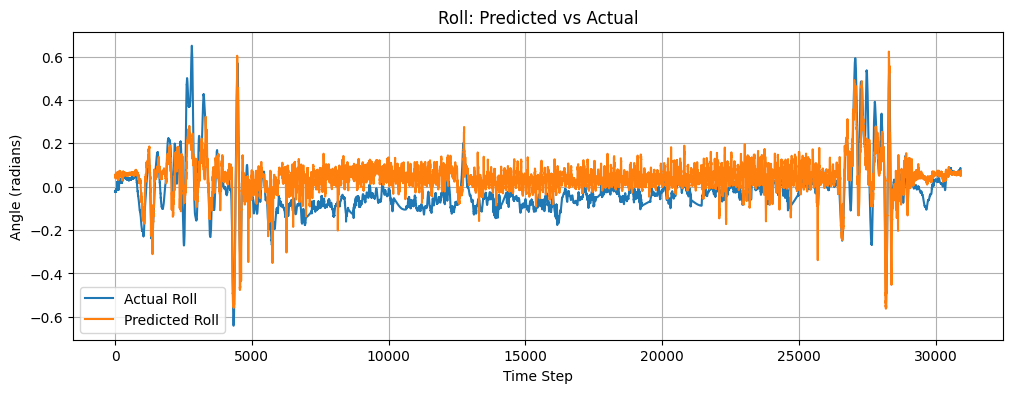

In [ ]:
# ROLL

plt.figure(figsize=(12,4))

plt.plot(y_test[:,0], label="Actual Roll")
plt.plot(y_pred[:,0], label="Predicted Roll")

plt.title("Roll: Predicted vs Actual")
plt.xlabel("Time Step")
plt.ylabel("Angle (radians)")
plt.legend()
plt.grid()

plt.show()

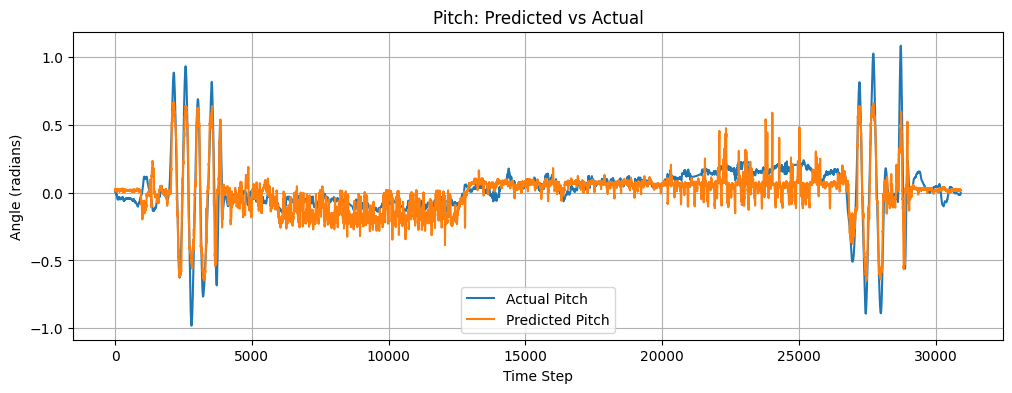

In [ ]:
# PITCH
plt.figure(figsize=(12,4))

plt.plot(y_test[:,1], label="Actual Pitch")
plt.plot(y_pred[:,1], label="Predicted Pitch")

plt.title("Pitch: Predicted vs Actual")
plt.xlabel("Time Step")
plt.ylabel("Angle (radians)")
plt.legend()
plt.grid()

plt.show()

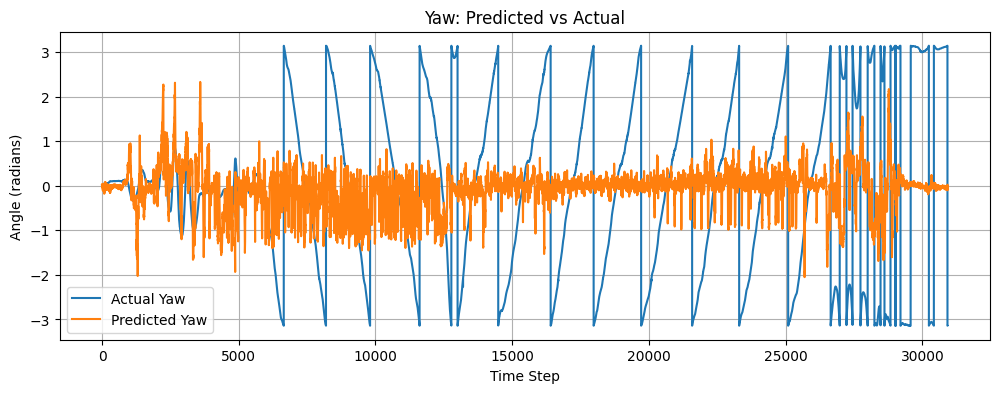

In [ ]:
# YAW
plt.figure(figsize=(12,4))

plt.plot(y_test[:,2], label="Actual Yaw")
plt.plot(y_pred[:,2], label="Predicted Yaw")

plt.title("Yaw: Predicted vs Actual")
plt.xlabel("Time Step")
plt.ylabel("Angle (radians)")
plt.legend()
plt.grid()

plt.show()

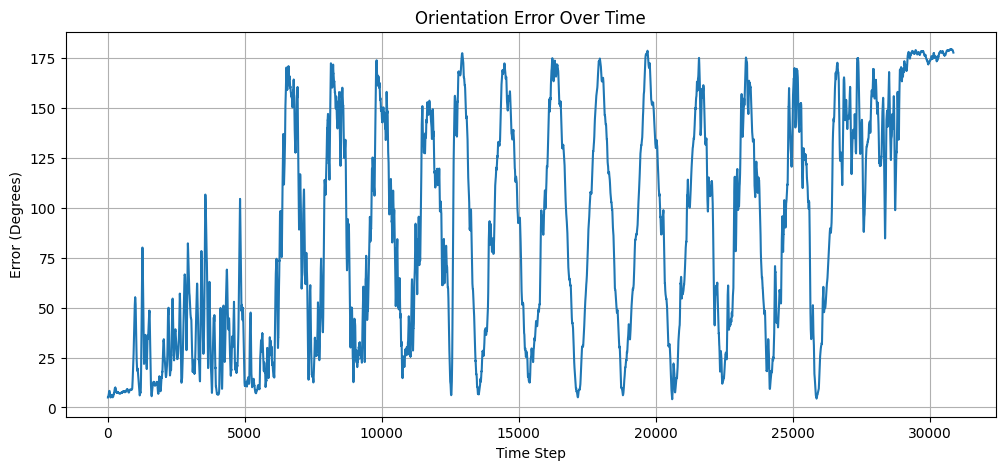

In [ ]:
# =========================
# PLOT ORIENTATION ERROR
# =========================

def moving_average(data, window_size=50):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Convert radians → degrees
angle_error_deg = np.degrees(angle_error)

smoothed_error = moving_average(angle_error_deg)

plt.figure(figsize=(12,5))
plt.plot(smoothed_error)

plt.title("Orientation Error Over Time")
plt.xlabel("Time Step")
plt.ylabel("Error (Degrees)")

plt.grid()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.7/244.7 kB 4.0 MB/s eta 0:00:00


/tmp/ipykernel_14525/3082811036.py:62: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  imu = pd.read_csv(imu_path, delim_whitespace=True)


          Method  Mean Quaternion Error (deg)  Median Quaternion Error (deg)  \
0            RNN                    87.970484                      85.283881   
1  Complementary                    55.120550                      59.273384   
2       Madgwick                     3.651225                       3.555411   

   Roll MAE (deg)  Pitch MAE (deg)  Yaw MAE (deg)  
0        5.100262         4.735674      87.079292  
1        4.267709         2.554400      54.593344  
2        1.269577         2.283862       2.103064  


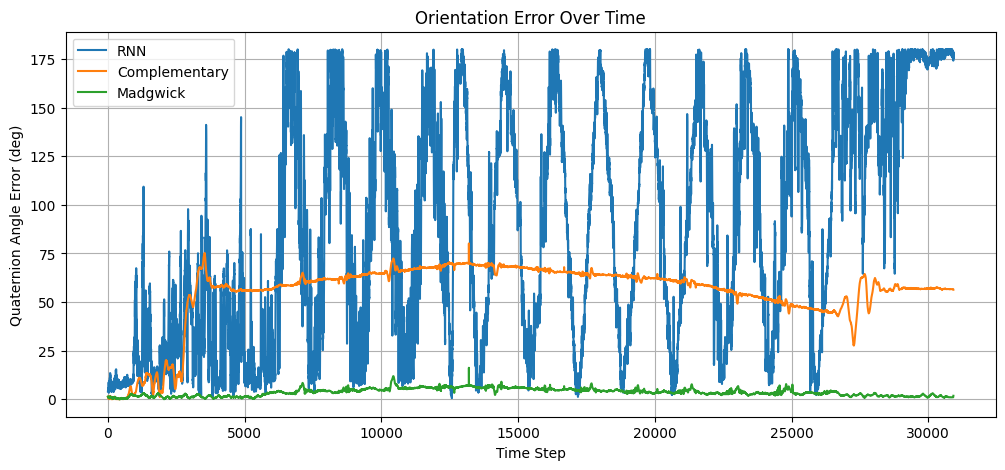

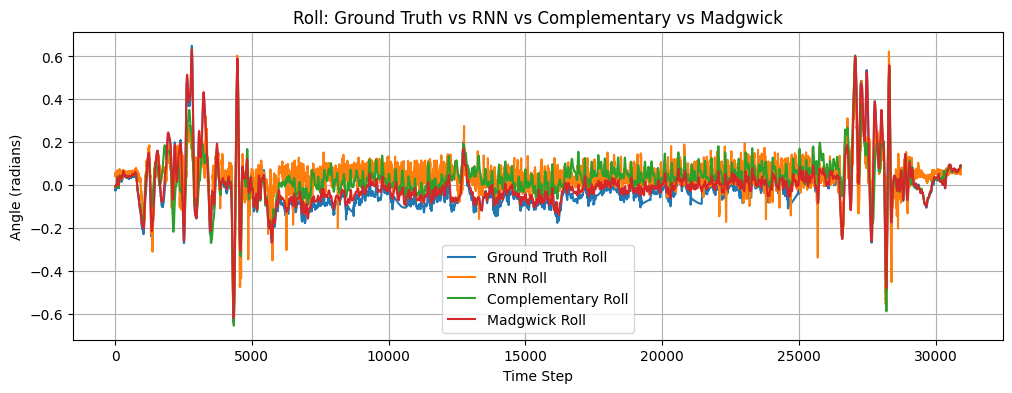

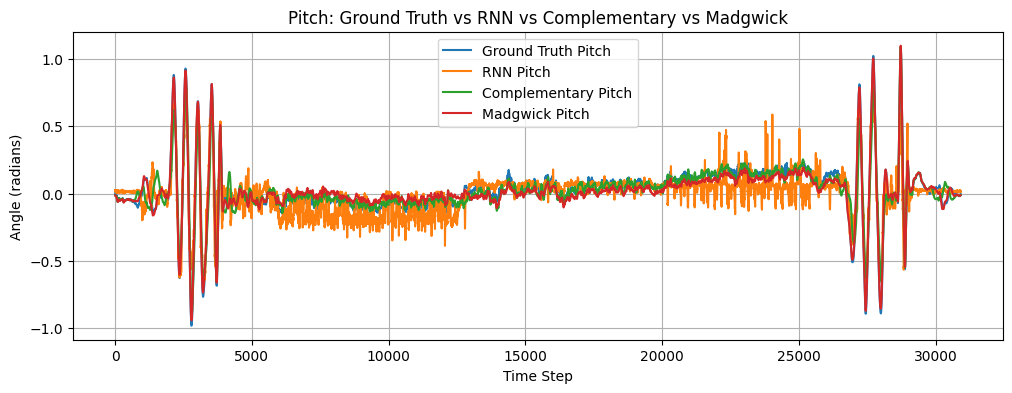

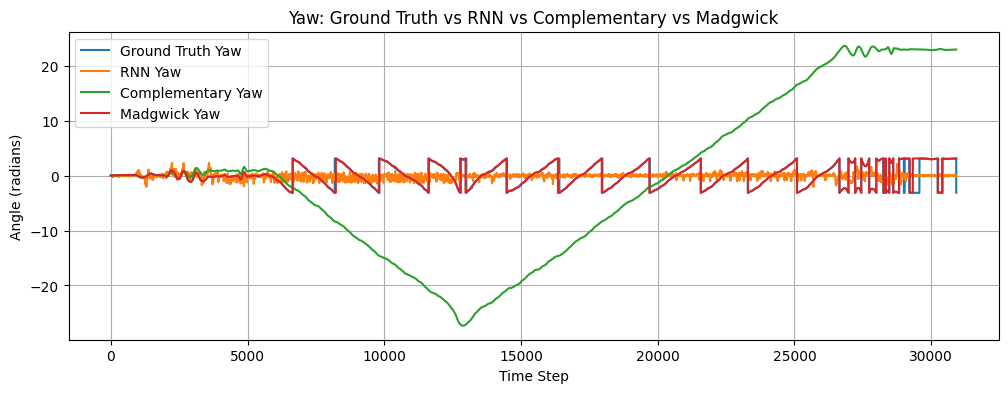

In [ ]:
# If needed:
!pip install -q ahrs

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.interpolate import interp1d
# from scipy.spatial.transform import Rotation as R
from ahrs.filters import Madgwick

# =========================
# HELPERS
# =========================
def auto_seconds(ts):
    ts = np.asarray(ts, dtype=np.float64)
    mx = np.nanmax(np.abs(ts))
    if mx > 1e14:      # nanoseconds
        return ts / 1e9
    elif mx > 1e11:    # microseconds
        return ts / 1e6
    elif mx > 1e8:     # milliseconds
        return ts / 1e3
    return ts          # already seconds

def normalize_quaternions(q):
    return q / np.linalg.norm(q, axis=1, keepdims=True)

def wrap_to_pi(a):
    return (a + np.pi) % (2.0 * np.pi) - np.pi

def quaternion_angle_error(q1_xyzw, q2_xyzw):
    q1 = normalize_quaternions(q1_xyzw)
    q2 = normalize_quaternions(q2_xyzw)
    dot = np.sum(q1 * q2, axis=1)
    dot = np.clip(dot, -1.0, 1.0)
    return 2.0 * np.arccos(np.abs(dot))

def euler_to_quat_xyzw(euler_xyz):
    return R.from_euler("xyz", euler_xyz, degrees=False).as_quat()

def compute_metrics(pred_euler, gt_euler):
    pred_q = euler_to_quat_xyzw(pred_euler)
    gt_q   = euler_to_quat_xyzw(gt_euler)

    quat_err_deg = np.degrees(quaternion_angle_error(gt_q, pred_q))
    ang_abs_deg = np.degrees(np.abs(wrap_to_pi(pred_euler - gt_euler)))

    return {
        "quat_mean_deg":   float(np.mean(quat_err_deg)),
        "quat_median_deg": float(np.median(quat_err_deg)),
        "roll_mae_deg":    float(np.mean(ang_abs_deg[:, 0])),
        "pitch_mae_deg":   float(np.mean(ang_abs_deg[:, 1])),
        "yaw_mae_deg":     float(np.mean(ang_abs_deg[:, 2])),
        "quat_err_series": quat_err_deg,
    }

# =========================
# LOAD TEST ROOM RAW DATA
# =========================
def load_test_room_raw(imu_path, gt_path):
    # IMU
    imu = pd.read_csv(imu_path, delim_whitespace=True)
    imu.columns = ["timestamp", "wx", "wy", "wz", "ax", "ay", "az"]

    # GT
    gt = pd.read_csv(gt_path)
    gt.columns = ["timestamp", "tx", "ty", "tz", "qw", "qx", "qy", "qz"]

    # Convert timestamps to seconds automatically
    imu["timestamp"] = auto_seconds(imu["timestamp"].values)
    gt["timestamp"]  = auto_seconds(gt["timestamp"].values)

    # Interpolate GT quaternion to IMU timestamps
    gt_interp = {}
    imu_t = imu["timestamp"].values
    gt_t  = gt["timestamp"].values

    for col in ["qw", "qx", "qy", "qz"]:
        f = interp1d(
            gt_t, gt[col].values,
            kind="linear",
            bounds_error=False,
            fill_value="extrapolate"
        )
        gt_interp[col] = f(imu_t)

    # Quaternion normalize after interpolation
    gt_q_wxyz = np.column_stack([
        gt_interp["qw"], gt_interp["qx"], gt_interp["qy"], gt_interp["qz"]
    ])
    gt_q_wxyz = normalize_quaternions(gt_q_wxyz)

    # Convert to scipy order: x, y, z, w
    gt_q_xyzw = np.column_stack([
        gt_q_wxyz[:, 1], gt_q_wxyz[:, 2], gt_q_wxyz[:, 3], gt_q_wxyz[:, 0]
    ])

    gt_euler = R.from_quat(gt_q_xyzw).as_euler("xyz", degrees=False)

    gyro = imu[["wx", "wy", "wz"]].values.astype(np.float64)
    acc  = imu[["ax", "ay", "az"]].values.astype(np.float64)

    t = imu["timestamp"].values.astype(np.float64)
    dt = np.diff(t, prepend=t[0])

    # first dt and safety clip
    if len(dt) > 1:
        dt[0] = np.median(dt[1:])
    dt = np.clip(dt, 1e-6, None)

    return gyro, acc, dt, gt_euler

# =========================
# COMPLEMENTARY FILTER
# =========================
# IMU-only version: roll/pitch corrected by accelerometer, yaw from gyro integration
def run_complementary_filter(gyro, acc, dt, alpha=0.98):
    n = len(gyro)
    euler = np.zeros((n, 3), dtype=np.float64)

    # Initial tilt from accelerometer
    ax, ay, az = acc[0]
    euler[0, 0] = np.arctan2(ay, az)                           # roll
    euler[0, 1] = np.arctan2(-ax, np.sqrt(ay**2 + az**2))     # pitch
    euler[0, 2] = 0.0                                          # yaw

    for i in range(1, n):
        ax, ay, az = acc[i]

        roll_acc  = np.arctan2(ay, az)
        pitch_acc = np.arctan2(-ax, np.sqrt(ay**2 + az**2))

        roll_gyro  = euler[i-1, 0] + gyro[i, 0] * dt[i]
        pitch_gyro = euler[i-1, 1] + gyro[i, 1] * dt[i]
        yaw_gyro   = euler[i-1, 2] + gyro[i, 2] * dt[i]

        euler[i, 0] = alpha * roll_gyro  + (1.0 - alpha) * roll_acc
        euler[i, 1] = alpha * pitch_gyro + (1.0 - alpha) * pitch_acc
        euler[i, 2] = yaw_gyro

    return euler

# =========================
# MADGWICK FILTER (IMU MODE)
# =========================
def run_madgwick_filter(gyro, acc, dt, gain=0.033):
    n = len(gyro)
    Q = np.zeros((n, 4), dtype=np.float64)  # w, x, y, z for ahrs

    # Initial attitude from accelerometer tilt
    ax, ay, az = acc[0]
    roll0  = np.arctan2(ay, az)
    pitch0 = np.arctan2(-ax, np.sqrt(ay**2 + az**2))
    yaw0   = 0.0

    q0_xyzw = R.from_euler("xyz", [roll0, pitch0, yaw0], degrees=False).as_quat()
    Q[0] = np.array([q0_xyzw[3], q0_xyzw[0], q0_xyzw[1], q0_xyzw[2]])  # w,x,y,z

    mad = Madgwick(gain=gain)

    for i in range(1, n):
        Q[i] = mad.updateIMU(Q[i-1], gyr=gyro[i], acc=acc[i], dt=float(dt[i]))

    # Convert ahrs order w,x,y,z -> scipy order x,y,z,w
    Q_xyzw = np.column_stack([Q[:, 1], Q[:, 2], Q[:, 3], Q[:, 0]])
    euler = R.from_quat(Q_xyzw).as_euler("xyz", degrees=False)

    return euler

# =========================
# LOAD RAW TEST ROOM
# =========================
gyro_test, acc_test, dt_test, gt_test_euler = load_test_room_raw("r3imu.txt", "r3gt_imu.csv")

# =========================
# RUN BASELINES
# =========================
comp_euler_full = run_complementary_filter(gyro_test, acc_test, dt_test, alpha=0.98)
madg_euler_full = run_madgwick_filter(gyro_test, acc_test, dt_test, gain=0.033)

# =========================
# ALIGN WITH RNN OUTPUT
# Your RNN predicts target at i + SEQ_LEN
# =========================
try:
    rnn_pred = y_pred.copy()   # from current notebook
except NameError:
    rnn_pred = np.load("y_pred.npy")

num_eval = len(rnn_pred)

gt_eval   = gt_test_euler[SEQ_LEN:SEQ_LEN + num_eval]
comp_eval = comp_euler_full[SEQ_LEN:SEQ_LEN + num_eval]
madg_eval = madg_euler_full[SEQ_LEN:SEQ_LEN + num_eval]

# If you want, you can also compare with saved y_test:
# rnn_gt = y_test.copy() if "y_test" in globals() else np.load("y_test.npy")

# =========================
# METRICS
# =========================
rnn_metrics  = compute_metrics(rnn_pred,  gt_eval)
comp_metrics = compute_metrics(comp_eval, gt_eval)
madg_metrics = compute_metrics(madg_eval, gt_eval)

results = pd.DataFrame([
    {
        "Method": "RNN",
        "Mean Quaternion Error (deg)": rnn_metrics["quat_mean_deg"],
        "Median Quaternion Error (deg)": rnn_metrics["quat_median_deg"],
        "Roll MAE (deg)": rnn_metrics["roll_mae_deg"],
        "Pitch MAE (deg)": rnn_metrics["pitch_mae_deg"],
        "Yaw MAE (deg)": rnn_metrics["yaw_mae_deg"],
    },
    {
        "Method": "Complementary",
        "Mean Quaternion Error (deg)": comp_metrics["quat_mean_deg"],
        "Median Quaternion Error (deg)": comp_metrics["quat_median_deg"],
        "Roll MAE (deg)": comp_metrics["roll_mae_deg"],
        "Pitch MAE (deg)": comp_metrics["pitch_mae_deg"],
        "Yaw MAE (deg)": comp_metrics["yaw_mae_deg"],
    },
    {
        "Method": "Madgwick",
        "Mean Quaternion Error (deg)": madg_metrics["quat_mean_deg"],
        "Median Quaternion Error (deg)": madg_metrics["quat_median_deg"],
        "Roll MAE (deg)": madg_metrics["roll_mae_deg"],
        "Pitch MAE (deg)": madg_metrics["pitch_mae_deg"],
        "Yaw MAE (deg)": madg_metrics["yaw_mae_deg"],
    }
])

print(results)

# =========================
# PLOT 1: ORIENTATION ERROR OVER TIME
# =========================
plt.figure(figsize=(12, 5))
plt.plot(rnn_metrics["quat_err_series"], label="RNN")
plt.plot(comp_metrics["quat_err_series"], label="Complementary")
plt.plot(madg_metrics["quat_err_series"], label="Madgwick")
plt.title("Orientation Error Over Time")
plt.xlabel("Time Step")
plt.ylabel("Quaternion Angle Error (deg)")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# PLOT 2/3/4: ROLL, PITCH, YAW
# =========================
labels = ["Roll", "Pitch", "Yaw"]

for i, label in enumerate(labels):
    plt.figure(figsize=(12, 4))
    plt.plot(gt_eval[:, i], label=f"Ground Truth {label}")
    plt.plot(rnn_pred[:, i], label=f"RNN {label}")
    plt.plot(comp_eval[:, i], label=f"Complementary {label}")
    plt.plot(madg_eval[:, i], label=f"Madgwick {label}")
    plt.title(f"{label}: Ground Truth vs RNN vs Complementary vs Madgwick")
    plt.xlabel("Time Step")
    plt.ylabel("Angle (radians)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
from google.colab import runtime
runtime.unassign()